In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme()

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/processed/cleaned_retail.csv")

print("Shape:", df.shape)

df.head()

Shape: (779425, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,01-12-2009 07:45,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,01-12-2009 07:45,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,01-12-2009 07:45,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,01-12-2009 07:45,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,01-12-2009 07:45,1.25,13085,United Kingdom,30.0


Dataset Information


In [3]:
print("\nDataset Info")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nSummary Statistics")
display(df.describe())


Dataset Info
<class 'pandas.DataFrame'>
RangeIndex: 779425 entries, 0 to 779424
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      779425 non-null  int64  
 1   StockCode    779425 non-null  str    
 2   Description  779425 non-null  str    
 3   Quantity     779425 non-null  int64  
 4   InvoiceDate  779425 non-null  str    
 5   Price        779425 non-null  float64
 6   Customer ID  779425 non-null  int64  
 7   Country      779425 non-null  str    
 8   Revenue      779425 non-null  float64
dtypes: float64(2), int64(3), str(4)
memory usage: 98.9 MB
None

Missing Values
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
Revenue        0
dtype: int64

Summary Statistics


,Invoice,Quantity,Price,Customer ID,Revenue
count,779425.000000,779425.000000,779425.000000,779425.000000,779425.000000
mean,537426.828586,13.489370,3.218488,15320.360461,22.291823
std,26901.629627,145.855814,29.676140,1695.692775,227.427075
min,489434.000000,1.000000,0.001000,12346.000000,0.001000
25%,514483.000000,2.000000,1.250000,13971.000000,4.950000
50%,536754.000000,6.000000,1.950000,15247.000000,12.480000
75%,561995.000000,12.000000,3.750000,16794.000000,19.800000
max,581587.000000,80995.000000,10953.500000,18287.000000,168469.600000


Converting Date

In [8]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["MonthName"] = df["InvoiceDate"].dt.strftime("%b")

In [9]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    format="%d-%m-%Y %H:%M",
    errors="coerce"
)

In [10]:
print(df["InvoiceDate"].isnull().sum())

0


In [11]:
df["Year"] = df["InvoiceDate"].dt.year

df["Month"] = df["InvoiceDate"].dt.month

df["MonthName"] = df["InvoiceDate"].dt.strftime("%b")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,MonthName
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009,12,Dec
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,Dec
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,Dec
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009,12,Dec
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009,12,Dec


KPI Analysis

In [12]:
total_revenue = df["Revenue"].sum()

total_customers = df["Customer ID"].nunique()

total_orders = df["Invoice"].nunique()

avg_order_value = total_revenue / total_orders

print("Total Revenue:", round(total_revenue,2))
print("Total Customers:", total_customers)
print("Total Orders:", total_orders)
print("Average Order Value:", round(avg_order_value,2))

Total Revenue: 17374804.27
Total Customers: 5878
Total Orders: 36969
Average Order Value: 469.98


Monthly Revenue Trend

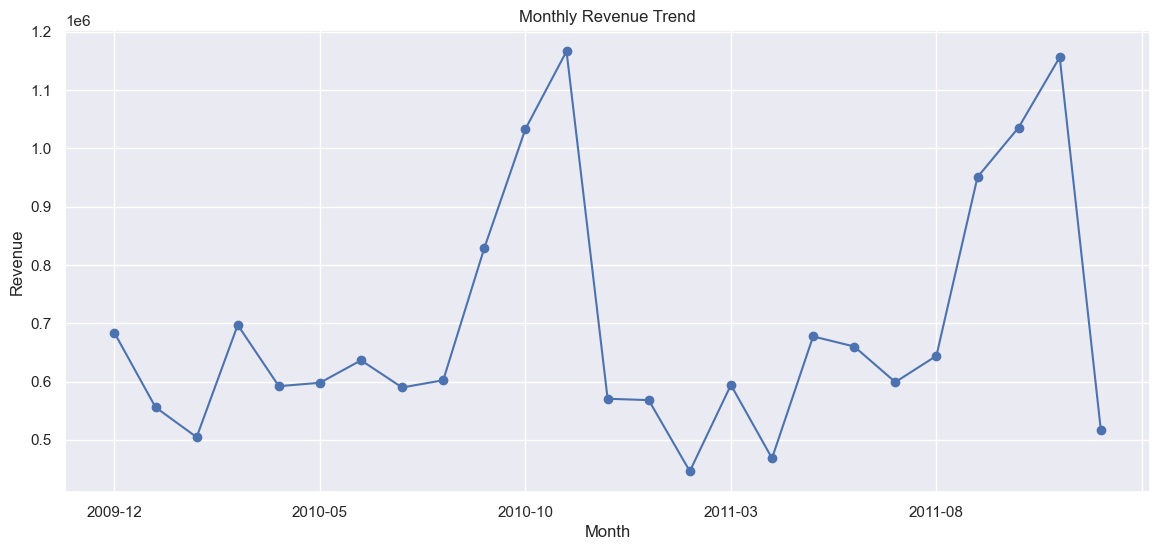

In [13]:
monthly_sales = (
    df.groupby(
        df["InvoiceDate"].dt.to_period("M")
    )["Revenue"]
    .sum()
)

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(14,6))

monthly_sales.plot(marker="o")

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.show()

Top products

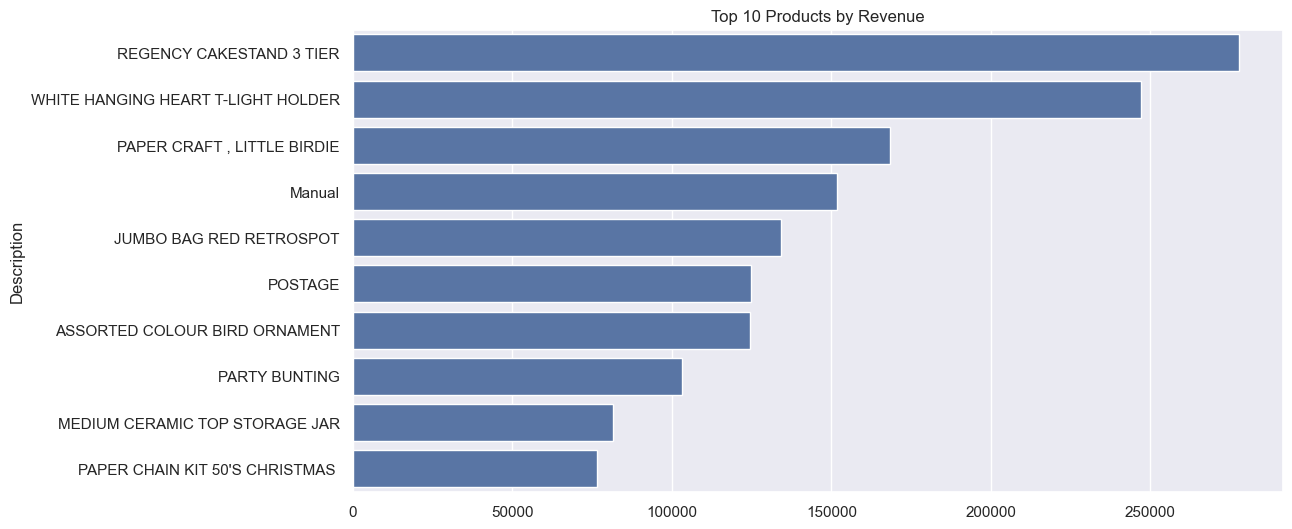

In [14]:
top_products = (
    df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Products by Revenue")

plt.show()

Top Countries

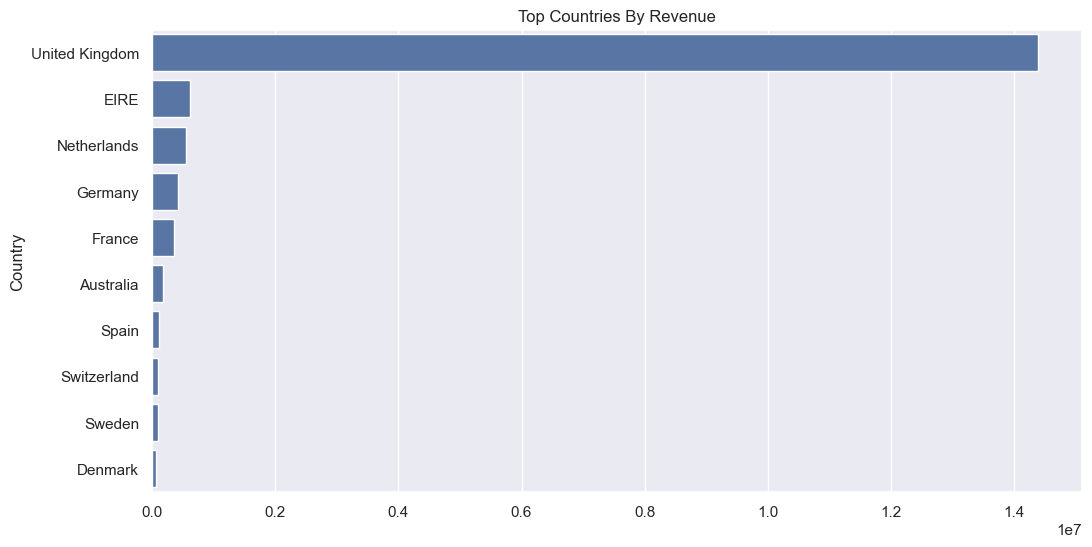

In [15]:
top_countries = (
    df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top Countries By Revenue")

plt.show()

Top Customers

In [16]:
top_customers = (
    df.groupby("Customer ID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

Customer ID
18102    580987.04
14646    528602.52
14156    313437.62
14911    291420.81
17450    244784.25
13694    195640.69
17511    172132.87
16446    168472.50
16684    147142.77
12415    144458.37
Name: Revenue, dtype: float64

Revenue Distribution

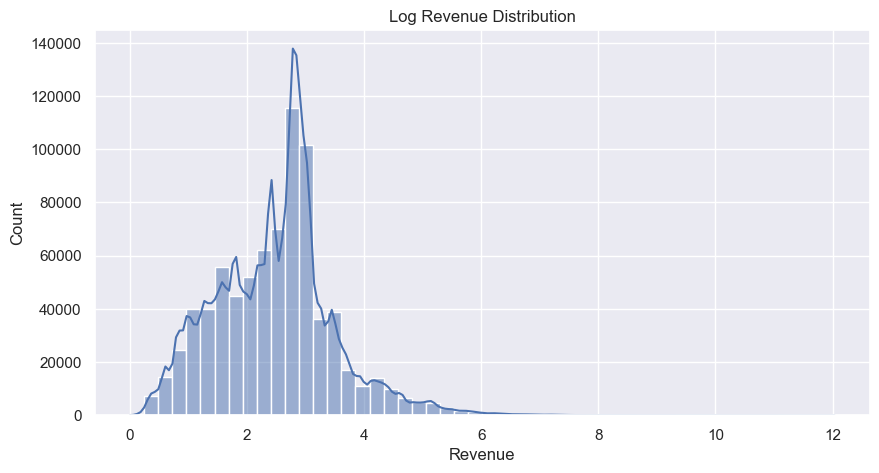

In [20]:
plt.figure(figsize=(10,5))

sns.histplot(
    np.log1p(df["Revenue"]),
    bins=50,
    kde=True
)

plt.title("Log Revenue Distribution")

plt.show()

Customer Purchase Frequency 

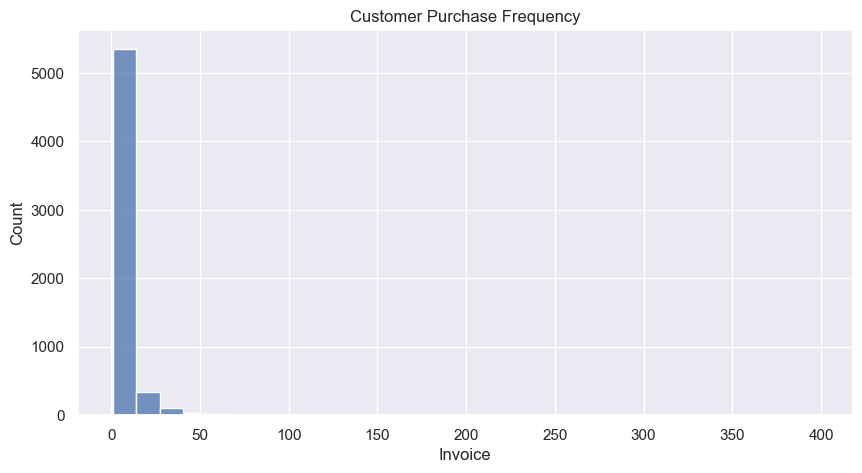

In [18]:
purchase_frequency = (
    df.groupby("Customer ID")["Invoice"]
    .nunique()
)

plt.figure(figsize=(10,5))

sns.histplot(
    purchase_frequency,
    bins=30
)

plt.title("Customer Purchase Frequency")

plt.show()

Monthly Order Trends

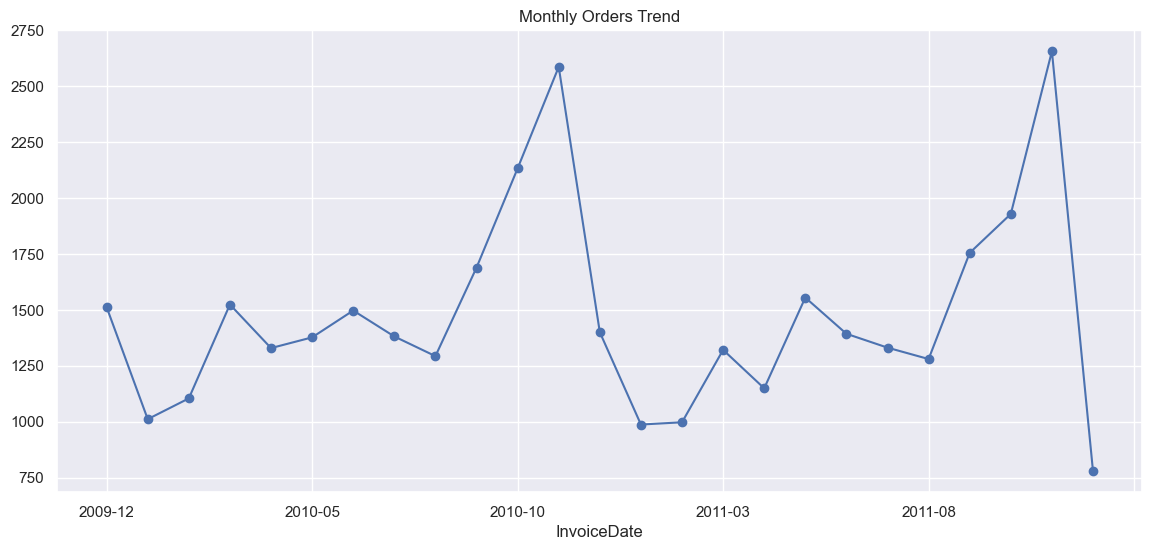

In [19]:
monthly_orders = (
    df.groupby(
        df["InvoiceDate"].dt.to_period("M")
    )["Invoice"]
    .nunique()
)

monthly_orders.index = monthly_orders.index.astype(str)

plt.figure(figsize=(14,6))

monthly_orders.plot(
    marker="o"
)

plt.title("Monthly Orders Trend")

plt.show()

Key Observations

Observation 1:
United Kingdom contributes the highest revenue.

Observation 2:
A small number of products generate most revenue.

Observation 3:
Revenue shows seasonal growth patterns.

Observation 4:
Customer purchasing behavior varies significantly.

Observation 5:
Some customers contribute disproportionately to total revenue.